# How do repeated measurements affect DVA

In [14]:
import os
import sys
import math
sys.path.append(os.path.join(os.getcwd().partition('EV_DVA_Robustnesss')[0], "EV_DVA_Robustnesss"))
from src.config_base import GeneralConfig

In [15]:
import pandas as pd
import numpy as np
import scipy as sp
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator, FixedLocator
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

In [16]:
from src.data.read_feather import ReadFeather
from src.filtering.filter_methods import FilterMethods
from src.voltage_capacity_analysis.ica import ICA
from src.voltage_capacity_analysis.dva import DVA
from src.visualization.config_visualization import VisualizationConfig, instantiate_matplotlib_parameters, cm2inch
instantiate_matplotlib_parameters()
from src.visualization.colormaps import ColorMaps

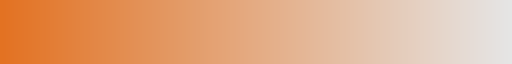

In [17]:
tum_orange_cmap = ColorMaps.orange_tum()
orange_colors = tum_orange_cmap(np.linspace(0,1, 3))
tum_orange_cmap

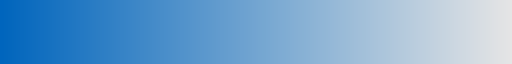

In [18]:
tum_blue_cmap = ColorMaps.blue_tum()
blue_colors = tum_blue_cmap(np.linspace(0,1, 5))
tum_blue_cmap

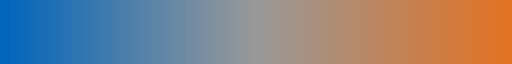

In [19]:
tum_cmap = ColorMaps.blue_orange_tum(grayscale=0.6)
colors = tum_cmap(np.linspace(1,0, 3))
tum_cmap

In [20]:
def filter_func_preprocess_U(signal):
    perc_filter = 1/100 * len(signal) #% filter
    filtered_signal = FilterMethods().rolling_mean_df(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter))
    #filtered_signal = FilterMethods().savgol(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return filtered_signal.values[:,0]

In [21]:
def filter_func_preprocess_Q(signal):
    perc_filter = 1/100 * len(signal) #% filter
    filtered_signal = FilterMethods().rolling_mean_df(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter))
    #filtered_signal = FilterMethods().savgol(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return filtered_signal

In [22]:
read_feather = ReadFeather()

In [23]:
%%capture
df_vw_213_1_E = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_213_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_213_2_E = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_213_JB_8A_CEE7_C45_repeatability.feather"), calc_E = True, lower_voltage=370, upper_voltage=450) 
df_vw_213_3_E = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_213_JB_8A_CEE7_C45_repeatability_2.feather"), calc_E = True, lower_voltage=370, upper_voltage=450)

In [24]:
read_feather.set_filter_U(filter_func_preprocess_U)
read_feather.set_filter_Q(filter_func_preprocess_Q)

## CU Data VW

In [25]:
%%capture
df_vw_213_1 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_213_JB_8A_CEE7_C45.feather"), calc_E = True, lower_voltage=0, upper_voltage=1000) 
df_vw_213_2 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_213_JB_8A_CEE7_C45_repeatability.feather"), calc_E = True, lower_voltage=0, upper_voltage=1000) 
df_vw_213_3 = read_feather.read(os.path.join(GeneralConfig.path2data.value,"Cupra","Cupra_213_JB_8A_CEE7_C45_repeatability_2.feather"), calc_E = True, lower_voltage=0, upper_voltage=1000)

In [26]:
E_mean_0_100 = np.mean([df_vw_213_1.E.max(),df_vw_213_2.E.max(),df_vw_213_3.E.max()])
print(E_mean_0_100)

61.100354401113826


In [27]:
E_std_0_100 = np.std([df_vw_213_1.E.max(),df_vw_213_2.E.max(),df_vw_213_3.E.max()])
print(E_std_0_100)

0.5696193216376755


In [28]:
E_std_0_100/E_mean_0_100*100

0.9322684413550499

In [29]:
np.std([13.3,12.7,12.9])

0.24944382578492996

In [30]:
print(round(df_vw_213_1.E.max()/58*100,1))
print(round(df_vw_213_2.E.max()/58*100,1))
print(round(df_vw_213_3.E.max()/58*100,1))

106.3
105.8
104.0


In [31]:
def filter_func_v(signal):
    perc_filter = 1 #% filter
    filtered_signal = FilterMethods().rolling_mean_numpy(signal,window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    filtered_signal_reverse = FilterMethods().rolling_mean_numpy(np.flip(signal),window_size=FilterMethods().round_to_next_odd_number(perc_filter/100 * len(signal)))
    return (filtered_signal+np.flip(filtered_signal_reverse))/2

In [32]:
Q_vw_213_1_370V = df_vw_213_1.Q[np.argmin(np.abs(df_vw_213_1.U-370))]
Q_vw_213_2_370V = df_vw_213_2.Q[np.argmin(np.abs(df_vw_213_2.U-370))]
Q_vw_213_3_370V = df_vw_213_3.Q[np.argmin(np.abs(df_vw_213_3.U-370))]

In [33]:
Q_vw_213_1_450V = df_vw_213_1.Q[np.argmin(np.abs(df_vw_213_1.U-450))]
Q_vw_213_2_450V = df_vw_213_2.Q[np.argmin(np.abs(df_vw_213_2.U-450))]
Q_vw_213_3_450V = df_vw_213_3.Q[np.argmin(np.abs(df_vw_213_3.U-450))]

In [34]:
Q_vw_213_1_450V-Q_vw_213_1_370V

143.63422301592638

In [35]:
Q_vw_213_2_450V-Q_vw_213_2_370V

143.56826976027062

In [36]:
Q_vw_213_3_450V-Q_vw_213_3_370V

142.56463911577654

In [37]:
dva_extractor = DVA()
dva_extractor.set_filter(filter_func_v)

In [38]:
dva_vw_213_1, cap_vw_213_1 = dva_extractor.get_dva(time=df_vw_213_1["time_h"], capacity=df_vw_213_1["Q"], voltage=df_vw_213_1["U"],crop_cap_Ah=(0,180))
dva_vw_213_2, cap_vw_213_2 = dva_extractor.get_dva(time=df_vw_213_2["time_h"], capacity=df_vw_213_2["Q"], voltage=df_vw_213_2["U"],crop_cap_Ah=(0,180))
dva_vw_213_3, cap_vw_213_3 = dva_extractor.get_dva(time=df_vw_213_3["time_h"], capacity=df_vw_213_3["Q"], voltage=df_vw_213_3["U"],crop_cap_Ah=(0,180))

## Plot

In [39]:
def bar_plot_soh(axes, X,y1,title = "",first_plot=True,lst_colors=colors,remove_tick_ind=None):    
    axes.spines['top'].set_color('black')
    axes.spines['left'].set_color('black')
    axes.spines['right'].set_color('black')
    
    width = 0.4 # the width of the bars      
    x = np.arange(len(X))*width 
    axes.set_xlim([-width,np.max(x)+width])
    for bar in range(len(x)):
        rects = axes.bar(x[bar], y1[bar], width,color=lst_colors[bar],edgecolor="k")
    #axes.bar_label(rects, padding=-50,rotation=90,fontsize=9,color="white")
    for label,pos in zip(y1,x):
        if label>0:
            label = round(label,1)
            axes.annotate(text=str(label)+" %",
                          xy=(pos,label-1),
                          horizontalalignment="center",
                          verticalalignment="top",
                          fontsize=6,color="w",rotation=90,)
                          #bbox=dict(boxstyle='square,pad=.0',fc='white', ec='white', alpha=0.75))
                        
    #axes.set_xticks(x)
    #tick_labels = [label for label in X]
    #axes.set_xticklabels(tick_labels,rotation=45,fontsize=7,ha='right',va="top",rotation_mode="anchor")
    axes.set_xlim([-0.5,1.08])
    axes.set_ylim([70,105])
    tick_positions = np.array([70,80,90,100])
    axes.set_yticks(tick_positions)
    #axes.yaxis.set_minor_locator(FixedLocator([75,85,95,105]))
    axes.tick_params(axis='y', colors='white',length=0)
    #axes.grid(axis='y')
    axes.set_axisbelow(True)
    axes.set_ylabel(r"$SOH_E$ in %",fontsize=6)
    axes.yaxis.set_label_coords(0.2,0.5)
    axes.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    axes.tick_params('x',  top=False, labeltop=False,bottom=False, labelbottom=False)
    #axes.set_title(r"$SOH_E$ in %",fontsize=6, y=0.65)
    return axes

In [40]:
def plot_pOCV_vw(axes, lst_dfs,lst_Q):
    color_ind =[0,1,2]
    for ind,data in enumerate(lst_dfs):
        axes.plot(lst_dfs[ind].Q-lst_Q[ind],lst_dfs[ind].U,color=colors[color_ind[ind]],linewidth=1.5)

    axes.scatter([0,143],[370,450],s=25,marker="*",color="k",edgecolor="k",zorder=3)
    axes.set_ylabel(r"Voltage in V",fontsize=9)
    axes.set_xlim([-10,160])
    tick_positions = np.array([-10,0,40,80,120,160])
    axes.set_xticks(tick_positions)
    _ = [x.set_horizontalalignment("right") for x in axes.get_xticklabels()[0:1]]
    axes.set_ylim([360,460])
    tick_positions = np.array([360,370,390,410,430,450,460])
    axes.set_yticks(tick_positions)
    axes.grid(axis='both')
    # Minor X-axis divided into 10 parts between each X-axis major grid
    axes.xaxis.set_minor_locator(FixedLocator([20,60,100,140]))
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=False)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)

    axes.axhline(y=450, xmin=0, xmax=1,linewidth=1,linestyle="--",color="dimgray")
    axes.axhline(y=370, xmin=0, xmax=1,linewidth=1,linestyle="--",color="dimgray")
    axes.axvline(x=0, ymin=0, ymax=1,linewidth=1,linestyle="--",color="dimgray")
    axes.axvline(x=143, ymin=0, ymax=1,linewidth=1,linestyle="--",color="dimgray")
    
    # kWh Axes
    twiny = axes.twiny()
    twiny.set_xlabel("Charged energy (aligned) in kWh",fontsize=9) 
    twiny.set_xlim(-10,160)
    tick_positions = np.array([-10,0,40,80,120,160])
    twiny.set_xticks(tick_positions)
    #_ = [x.set_horizontalalignment("right") for x in twiny.get_xticklabels()[0:1]]
    twiny.xaxis.set_minor_locator(FixedLocator([20,60,100,140]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([f"{x*lst_dfs[ind].U.mean()/1000:.0f}" for x in tick_positions])
    # close up 1
    axins = axes.inset_axes([45, 364,30,25],transform = axes.transData) # [x0, y0, width, height]
    for ind,data in enumerate(lst_dfs):
        axins.plot(lst_dfs[ind].Q-lst_Q[ind],lst_dfs[ind].U,color=colors[color_ind[ind]],linewidth=1.5)
    axins.scatter([0,143],[370,450],s=25,marker="*",color="k",edgecolor="k",zorder=3)
    # subregion of the original image
    x1, x2, y1, y2 = -5, 2, 359,373
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_xticklabels([])
    axins.set_yticklabels([])
    axes.indicate_inset_zoom(axins, edgecolor="black")
    axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    axins.annotate(text='A', xy=(-4.85,370), xytext=(-4.85,368),fontsize=9)
    # close up 2
    axins = axes.inset_axes([110, 395,30,25],transform = axes.transData) # [x0, y0, width, height]
    for ind,data in enumerate(lst_dfs):
        axins.plot(lst_dfs[ind].Q-lst_Q[ind],lst_dfs[ind].U,color=colors[color_ind[ind]],linewidth=1.5)
    axins.scatter([0,143],[370,450],s=25,marker="*",color="k",edgecolor="k",zorder=3)
    # subregion of the original image
    x1, x2, y1, y2 = 140, 148, 448, 455
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_xticklabels([])
    axins.set_yticklabels([])
    axes.indicate_inset_zoom(axins, edgecolor="black")
    axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    axins.annotate(text='B', xy=(140.3,452.6), xytext=(140.3,452.6),fontsize=9)

    #insert axes right
    E_nom_VW = 58
    axins = axes.inset_axes([2, 412,36,36],transform = axes.transData) # [x0, y0, width, height]
    bar_plot_soh(axins, X=[0,1,2],y1=np.hstack(np.array([df_vw_213_1_E.E.max(),df_vw_213_2_E.E.max(),df_vw_213_3_E.E.max()])/E_nom_VW*100))
    return axes

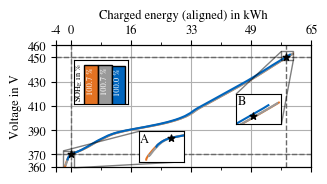

In [41]:
fig, axes= plt.subplots(1,1,
                        figsize=(VisualizationConfig.columnwidth_in_in.value,
                                cm2inch(4)))
axes = plot_pOCV_vw(axes,lst_dfs = [df_vw_213_1,df_vw_213_2,df_vw_213_3],lst_Q = [Q_vw_213_1_370V,Q_vw_213_2_370V,Q_vw_213_3_370V])

In [42]:
def find_H2_peak(cap,dva,Q_min,Q_max):
    maskQ = (cap>Q_min)&(cap<Q_max)

    tmp_Q = cap[maskQ]
    tmp_dva = dva[maskQ]

    def func(x,a,b,c):
        return a*x**2 + b*x + c

    popt, pcov = curve_fit(func, tmp_Q, tmp_dva)

    return tmp_Q, func(tmp_Q, *popt)

In [43]:
def find_max_min(cap,dva,xmin,xmax,maximum=True):
    if maximum:
        ypos = np.max(dva[(cap>xmin)&(cap<xmax)])
    else:
        ypos = np.min(dva[(cap>xmin)&(cap<xmax)])
    xpos = cap[dva==ypos]
    return xpos[0], ypos

In [44]:
def plot_dva_vw(axes,
                  lst_cap, lst_dva, lst_Q):
    color_ind =[0,1,2]
    Q_nom = 78*2
    for ind,data in enumerate(lst_cap):
        axes.plot(lst_cap[ind]-lst_Q[ind],lst_dva[ind]*Q_nom, color=colors[color_ind[ind]], linewidth=1.5)
        xpos, ypos = find_max_min(lst_cap[ind], lst_dva[ind]*Q_nom, xmin=70, xmax=90, maximum=True)
        #axes.scatter(xpos-lst_Q[ind],ypos,marker="d",color=colors[color_ind[ind]],edgecolors="k",zorder=3)

        xcap, yDVA = find_H2_peak(cap = lst_cap[ind],dva = lst_dva[ind]*Q_nom,Q_min=115,Q_max=145)
        maxDVA = np.argmax(yDVA)
        #axes.scatter(xcap[maxDVA]-lst_Q[ind],yDVA[maxDVA],marker="o",color=colors[color_ind[ind]],edgecolors="k",zorder=3)
   
    axes.set_ylabel(r"$Q_{N}\cdot \frac{dU}{dQ}$ in V",fontsize=9)
    axes.set_xlabel(r"Charged capacity (aligned) in Ah",fontsize=9) 
    axes.set_xlim([-10,160])
    tick_positions = np.array([-10,0,40,80,120,160])
    axes.set_xticks(tick_positions)
    _ = [x.set_horizontalalignment("right") for x in axes.get_xticklabels()[0:1]]
   
    axes.xaxis.set_minor_locator(FixedLocator([20,60,100,140]))
    axes.set_ylim([0,162])
    tick_positions = np.array([0,0.5,1,1.5])*108
    axes.set_yticks(tick_positions)
    axes.grid(axis='both')
    
    axes.set_axisbelow(True)
    axes.tick_params('x', top=False, labeltop=False,bottom=True, labelbottom=True)
    axes.tick_params('y', left=True, labelleft=True,right=False, labelright=False)
    axes.tick_params(axis='x', labelsize=9)
    axes.tick_params(axis='y', labelsize=9)
    axes.yaxis.set_label_coords(-0.11,0.5)

    axes.annotate(text='A', xy=(8,74), xytext=(17,59),fontsize=9,
                      arrowprops=dict(arrowstyle='-', shrinkA=0, shrinkB=0,facecolor="k", mutation_scale=20))

    axes.axvline(x=0, ymin=0, ymax=1,linewidth=1,linestyle="--",color="dimgray")
    axes.axvline(x=143, ymin=0, ymax=1,linewidth=1,linestyle="--",color="dimgray")
    twiny = axes.twiny() 
    twiny.set_xlim(-10,160)
    tick_positions = np.array([-10,0,40,80,120,160])
    twiny.set_xticks(tick_positions)
    twiny.xaxis.set_minor_locator(FixedLocator([20,60,100,140]))
    twiny.tick_params(axis='x', labelsize=9)
    twiny.set_xticklabels([])

    # close up 1
    axins = axes.inset_axes([34, 80,35,70],transform = axes.transData) # [x0, y0, width, height]
    for ind,data in enumerate(lst_cap):
        axins.plot(lst_cap[ind]-lst_Q[ind],lst_dva[ind]*Q_nom, color=colors[color_ind[ind]], linewidth=1.5)
        xpos, ypos = find_max_min(lst_cap[ind], lst_dva[ind]*Q_nom, xmin=70, xmax=90, maximum=True)
        axins.scatter(xpos-lst_Q[ind],ypos,marker="d",color=colors[color_ind[ind]],edgecolors="k",zorder=3)
    # subregion of the original image
    x1, x2, y1, y2 = 75, 90, 100,152
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_xticklabels([])
    axins.set_yticklabels([])
    axes.indicate_inset_zoom(axins, edgecolor="black")
    axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    axins.annotate(text='B', xy=(75.25,141), xytext=(75.25,141),fontsize=9)
    # close up 2
    axins = axes.inset_axes([85, 15,55,60],transform = axes.transData) # [x0, y0, width, height]
    for ind,data in enumerate(lst_cap):
        axins.plot(lst_cap[ind]-lst_Q[ind],lst_dva[ind]*Q_nom, color=colors[color_ind[ind]], linewidth=1.5)
        xcap, yDVA = find_H2_peak(cap = lst_cap[ind],dva = lst_dva[ind]*Q_nom,Q_min=115,Q_max=145)
        maxDVA = np.argmax(yDVA)
        axins.scatter(xcap[maxDVA]-lst_Q[ind],yDVA[maxDVA],marker="o",color=colors[color_ind[ind]],edgecolors="k",zorder=3)
    # subregion of the original image
    x1, x2, y1, y2 = 120, 143, 115, 128
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_xticklabels([])
    axins.set_yticklabels([])
    axes.indicate_inset_zoom(axins, edgecolor="black")
    axins.tick_params('x', top=False, labeltop=False,bottom=False, labelbottom=False)
    axins.tick_params('y', left=False, labelleft=False,right=False, labelright=False)
    axins.annotate(text='C', xy=(120.5,125), xytext=(120.5,125),fontsize=9)
    return axes

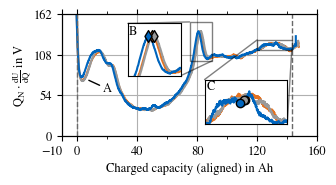

In [45]:
fig, axes= plt.subplots(1,1,
                        figsize=(VisualizationConfig.columnwidth_in_in.value,
                                cm2inch(4)))
axes = plot_dva_vw(axes,
                    lst_cap = [cap_vw_213_1,cap_vw_213_2,cap_vw_213_3],
                    lst_dva = [dva_vw_213_1,dva_vw_213_2,dva_vw_213_3],
                        lst_Q = [Q_vw_213_1_370V,Q_vw_213_2_370V,Q_vw_213_3_370V])

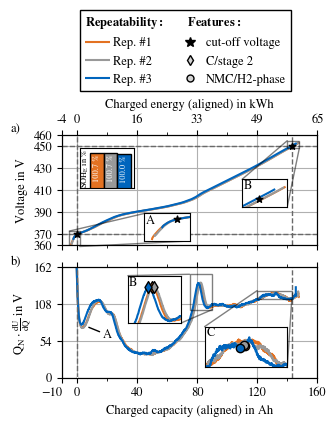

In [46]:
n_rows = 2
heigth = 4 #cm
fig, axes= plt.subplots(n_rows,1,
                        figsize=(VisualizationConfig.columnwidth_in_in.value,
                                n_rows*cm2inch(heigth)))

axes[0] = plot_pOCV_vw(axes[0],
                          lst_dfs = [df_vw_213_1,df_vw_213_2,df_vw_213_3],lst_Q = [Q_vw_213_1_370V,Q_vw_213_2_370V,Q_vw_213_3_370V])

axes[1] = plot_dva_vw(axes[1],
                    lst_cap = [cap_vw_213_1,cap_vw_213_2,cap_vw_213_3],
                    lst_dva = [dva_vw_213_1,dva_vw_213_2,dva_vw_213_3],
                        lst_Q = [Q_vw_213_1_370V,Q_vw_213_2_370V,Q_vw_213_3_370V])


# plt.tight_layout()

axes[0].text(-0.2, 1.05, 'a)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=axes[0].transAxes)
axes[1].text(-0.2, 1.05, r'b)', horizontalalignment='left',fontsize=9,
     verticalalignment='center', transform=axes[1].transAxes)
# legend
handles, labels =axes[0].get_legend_handles_labels()  
line1 = plt.hlines(-7,0,1,label="Rep. #1", color=colors[0])
line2 = plt.hlines(-7,0,1,label="Rep. #2", color=colors[1])
line3 = plt.hlines(-7,0,1,label="Rep. #3", color=colors[2])
marker1 =mlines.Line2D([], [], color='k', marker='*',linestyle="none",markeredgecolor="k",
                          markersize=7, label=r'cut-off voltage')
line4 = plt.hlines(0,0,1,label=" ", color="white")
marker2 =mlines.Line2D([], [], color='lightgray', marker='d',linestyle="None",markeredgecolor="k",
                          markersize=5, label=r'C/stage 2')
marker3 =  mlines.Line2D([], [], color='lightgray', marker='o',linestyle="None",markeredgecolor="k",
                          markersize=5, label=r'NMC/H2-phase')
lgd=fig.legend(handles=[line1,line2,line3,marker1,marker2, marker3],loc="center",fontsize=9,ncols=2,handletextpad=0.3,
            framealpha =1 , fancybox=False,columnspacing=2,edgecolor="black",bbox_to_anchor=(0.5,1.15),title=r"$\bf{Repeatability:}$"+"\t"+r"    $\bf{Features:}$",alignment='left')

fig.savefig(os.path.join(GeneralConfig.path2figures.value,"06-FIG-Repeatability.pdf"), bbox_inches='tight') 
fig.savefig(os.path.join(GeneralConfig.path2figures.value,"06-FIG-Repeatability.png"),dpi=300, pad_inches = 0) 